In [1]:
import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from confidence.model.single_pass import SinglePassConfidence
from model.classifier import Classifier, MyProgressBar
from utils.transforms.apply import grid_resample

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from its.transform import multi_transform
from utils.affine_transforms import AffineTransformation2D
from dataset.mnist_no_pil import NoPILMNIST, NoPILFashionMNIST, AffineTransformDataset

dataset = 'mnist' # or 'fmnist'
batch_size = 128
#divide by 255 transform


if dataset == 'mnist':
    # essentially excluding either 6 or 9 as these would cause degenerations under 180 degree rotation
    dataset_train = NoPILMNIST("../experiment_files/data",train=True,download=True)
    n_classes = 10
    dataset_val_test = NoPILMNIST("../experiment_files/data",train=False,download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = #fix this, use val from train as this is what is usually expected.
elif dataset == 'fmnist':
    dataset_train = NoPILFashionMNIST("../experiment_files/data",train=True,download=True)
    n_classes = 10
    dataset_val_test = NoPILFashionMNIST("../experiment_files/data",train=False,download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = #fix this, use val from train as this is what is usually expected.



transformations = [AffineTransformation2D.ROTATION.value,AffineTransformation2D.SHEARING_X.value,AffineTransformation2D.SHEARING_Y.value
                     ,AffineTransformation2D.SCALING_X.value,AffineTransformation2D.SCALING_Y.value]
domains = [(-torch.pi,torch.pi), ((-0.5, 0.5),), ((-0.5, 0.5),), ((1/1.3-1, 0.3),), ((1/1.3-1, 0.3),)]
n_samples = 17

def transform(batch_size):
    n = torch.randint(0, n_samples, (batch_size, len(transformations)), device="cpu")
    x_test = torch.zeros(batch_size, 1, 28, 28, device="cpu")
    _, _, T = multi_transform(x_test, transformations, n, n_samples=n_samples, domain=domains)
    return T


dataset_test = AffineTransformDataset(dataset_test_pre,transform,return_transformation=False,batch_size=batch_size)


In [3]:
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True, num_workers=4,persistent_workers=True)
val_loader = torch.utils.data.DataLoader(dataset_val, batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True)
test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True)

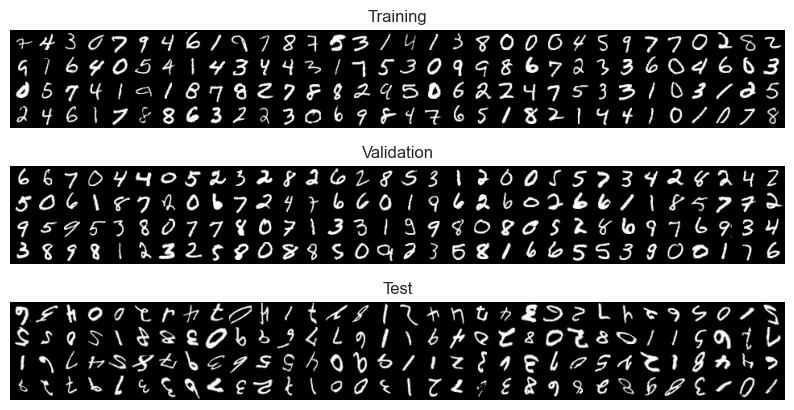

In [4]:
#test images
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 5))

axs[0].imshow(torchvision.utils.make_grid(next(iter(train_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[1].imshow(torchvision.utils.make_grid(next(iter(val_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[2].imshow(torchvision.utils.make_grid(next(iter(test_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[0].set_title('Training')
axs[1].set_title('Validation')
axs[2].set_title('Test')

for ax in axs.flat:
    ax.axis('off')

In [5]:
import pytorch_lightning as pl
import os

model_path = f'../model/{dataset}.pth'

model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 32x14x14
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)


# Check if model is already trained
if os.path.exists(model_path):
    print(f"Loading model from {model_path}")
    model.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")
    lightning_model = Classifier(model, optimizer_class =  torch.optim.AdamW, optimizer_params = {"lr": 1e-3})
    progress_bar = MyProgressBar()
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=10,
        precision="16-mixed",
        callbacks=[progress_bar],
    )
    # Train the model
    trainer.fit(lightning_model, train_loader,val_loader)
    # Test the model
    #trainer.test(lightning_model, test_loader)
    # Save model
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")

Loading model from ../model/mnist.pth


In [6]:
#calibrate the model
#from confidence.calibration import TemperatureCalibrationModule
#if model is not temperature calibrated
#if isinstance(model, TemperatureCalibrationModule):
    #model = model.model
#model = TemperatureCalibrationModule(model,per_logit=True).cuda()
#model.fit(test_loader)


In [7]:
model.cuda()

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=3136, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)

In [8]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in val_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_val)
    print(f'Mean accuracy on the val set: {test_acc}.')

Mean accuracy on the val set: 0.9884.


In [9]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set: {test_acc}.')

Mean accuracy on the transformed test set: 0.3352.


In [10]:
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from its.search import InverseTransformationSearch
confidence_module = SinglePassConfidence(model, EnergyConfidence())
its = InverseTransformationSearch(model, transformation=transformations, domain=domains,
                                  n_samples=17, n_hypotheses=1, mc_steps=1,
                                  change_of_mind='score', en_unique_class_condition=True,gaussian_filter_channel_wise=False,confidence_module=confidence_module)



with torch.no_grad():
    model.eval()
    test_acc = 0
    for d, (data, target) in enumerate(test_loader):
        data, target = data.cuda(), target.cuda()
        data_canonic, embedding = its.infer(data, plot_idx=None)
        # pick the class of the leading hypothesis
        output = embedding.argmax(dim=-1)[:, 0]
        test_acc += output.eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set [but with ITS]: {test_acc}.')

Mean accuracy on the transformed test set [but with ITS]: 0.7614.


In [11]:
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from its.search import InverseTransformationSearch
confidence_module = SinglePassConfidence(model, EnergyConfidence())
its = InverseTransformationSearch(model, transformation=transformations, domain=domains,
                                  n_samples=17, n_hypotheses=1, mc_steps=1,
                                  change_of_mind='score', en_unique_class_condition=True,gaussian_filter_channel_wise=False,confidence_module=None)



with torch.no_grad():
    model.eval()
    test_acc = 0
    for d, (data, target) in enumerate(test_loader):
        data, target = data.cuda(), target.cuda()
        data_canonic, embedding = its.infer(data, plot_idx=None)
        # pick the class of the leading hypothesis
        output = embedding.argmax(dim=-1)[:, 0]
        test_acc += output.eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set [but with ITS]: {test_acc}.')

Mean accuracy on the transformed test set [but with ITS]: 0.6456.


In [12]:
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from its_unchanged.search import InverseTransformationSearch as InverseTransformationSearchUnchanged
domains_original = (((-torch.pi, torch.pi),), ((-0.5, 0.5),), ((-0.5, 0.5),), ((1/1.3-1, 0.3),), ((1/1.3-1, 0.3),))

confidence_module = SinglePassConfidence(model, EnergyConfidence())
its = InverseTransformationSearchUnchanged(model, transformation=transformations, domain=domains_original,
                                  n_samples=17, n_hypotheses=1, mc_steps=1,
                                  change_of_mind='score', en_unique_class_condition=True,)



with torch.no_grad():
    model.eval()
    test_acc = 0
    for d, (data, target) in enumerate(test_loader):
        data, target = data.cuda(), target.cuda()
        data_canonic, embedding = its.infer(data, plot_idx=None)
        # pick the class of the leading hypothesis
        output = embedding.argmax(dim=-1)[:, 0]
        test_acc += output.eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set [but with ITS]: {test_acc}.')

C:\Users\Lindner\PycharmProjects\experiments_rotation\its_unchanged\search.py:216: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return -curvature(torch.tensor(energies, device=z.device))


Mean accuracy on the transformed test set [but with ITS]: 0.6456.


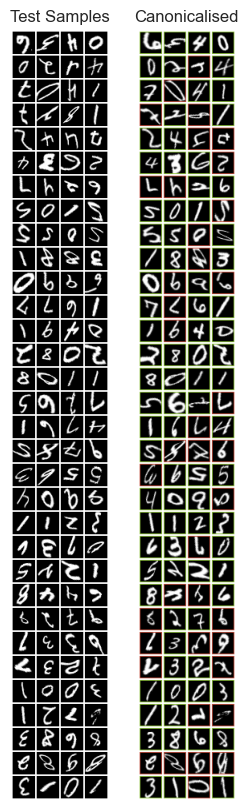

In [13]:
data, target = next(iter(test_loader))
data_canonic, embedding = its.infer(data.cuda())
output = embedding.argmax(dim=-1)[:, 0]
correct_label = output.eq(target.cuda())

# highlight correct predictions with green frame
green = torch.tensor((143, 194, 62))[:, None] / 255.
red = torch.tensor((194, 80, 62))[:, None] / 255.
data_canonic = data_canonic[:, 0].repeat(1, 3, 1, 1)
for image, correct in zip(data_canonic, correct_label):
    color = green if correct else red
    image[:, :, 0] = color
    image[:, :, 27] = color
    image[:, 0, :] = color
    image[:, 27, :] = color

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(3, 10))

axs[0].imshow(torchvision.utils.make_grid(data.cpu(), nrow=4, pad_value=1).permute(1, 2, 0), cmap='gray')
axs[1].imshow(torchvision.utils.make_grid(data_canonic.cpu(), nrow=4, pad_value=1).permute(1, 2, 0))

axs[0].set_title('Test Samples')
axs[1].set_title('Canonicalised')

for ax in axs.flat:
    ax.axis('off')